# Seleção de campos para estimar a marcação de emergência

Este experimento independente usa `public.disque100_reports` e pergunta: **o DAMICORE ajuda um algoritmo de estimação de distribuição (AED) a encontrar formulários com menos campos, mantendo a qualidade da estimativa probabilística?** Comparamos a busca guiada pelo DAMICORE com buscas independente e aleatória, sempre com o mesmo orçamento de soluções avaliadas.

O alvo é a **marcação histórica de emergência** na denúncia. Ele não confirma a gravidade real nem mede o efeito de uma decisão de atendimento. O notebook não usa resultados da hipótese anterior. Todos os resultados quantitativos abaixo são produzidos pela execução no banco; o único exemplo inventado está identificado como didático. Se o banco não responder, a execução para sem substituir a fonte por CSV.

In [1]:
from dataclasses import asdict
from pathlib import Path
import sys

from IPython.display import SVG, display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import toytree

PROJECT_ROOT = next(path for path in (Path.cwd(), *Path.cwd().parents) if (path / 'pyproject.toml').exists())
sys.path.insert(0, str(PROJECT_ROOT))

from hypotheses.emergency_feature_selection.pipeline.config import DEFAULT_CONFIG, FEATURES, NEGATIVE_STATUS, POSITIVE_STATUSES
from hypotheses.emergency_feature_selection.pipeline.data import prepare_data
from hypotheses.emergency_feature_selection.pipeline.experiment import execute_experiment

/Users/erickpatrickbarcelos/codes/data-mining/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. O que será medido

Uma solução é um vetor com 15 decisões, uma para cada campo contextual. O objetivo é **minimizar o número de campos** sem perder mais do que os limites de qualidade definidos em relação ao modelo que usa todos eles. O custo de coletar cada campo ainda é tratado como igual; isso não equivale ao esforço real de um formulário.

Os parâmetros ficam visíveis aqui para que orçamento, amostragem e tolerâncias não sejam decisões escondidas no código.

In [2]:
display(pd.DataFrame({'posição': range(1, len(FEATURES) + 1), 'campo': FEATURES}))
display(pd.DataFrame([asdict(DEFAULT_CONFIG)]).T.rename(columns={0: 'valor'}))

,posição,campo
0,1,service_channel
1,2,reporter_type
2,3,violation_setting
3,4,frequency
4,5,violation_start_period
5,6,vulnerable_group
6,7,motivation
7,8,victim_suspect_relationship
8,9,victim_gender
9,10,victim_age_group


,valor
search_train_limit,50000
validation_limit,30000
final_train_limit,200000
initial_pool_size,64
elite_size,32
generations,5
offspring_per_generation,16
random_exploration,0.05
max_block_size,4
top_fraction,0.05


### Exemplo exclusivamente didático: dois usos diferentes de 0 e 1

Imagine uma denúncia **inventada** cuja marcação seja ‘NÃO’: seu **alvo** é `0`. Se a marcação fosse uma das categorias de emergência definidas para este estudo, o alvo seria `1`. Esse número pertence à denúncia e é aquilo que a regressão logística tenta estimar.

Agora imagine apenas três campos, `service_channel`, `frequency` e `victim_age_group`, para facilitar a leitura. A solução fictícia `[1, 0, 1]` significa **usar** o primeiro e o terceiro campo e **não usar** o segundo. Esses bits pertencem à escolha do formulário, não à denúncia. No experimento real, cada solução tem 15 bits. Nada deste exemplo é passado ao banco, ao DAMICORE ou ao modelo.

## 2. Dados reais: uma denúncia por registro

A tabela pode ter várias linhas para a mesma denúncia. A preparação reúne essas linhas por `source_hash` **dentro do PostgreSQL**; o identificador não sai do banco. Datas ou marcações de emergência conflitantes, ausentes ou não reconhecidas são excluídas. Valores contextuais conflitantes tornam-se a categoria `MULTIPLE`; ausentes tornam-se `UNKNOWN`. `emergency_status`, `violation`, datas e identificadores não são preditores.

Treino da busca: 2024–2025; escolha das soluções: janeiro–março de 2026; avaliação final intocada: abril–junho de 2026. A busca usa no máximo 50 mil denúncias de treino e 30 mil de validação; o reajuste final usa no máximo 200 mil denúncias anteriores ao teste. Essas seleções são determinísticas e preservam a proporção das duas classes, mas **não garantem representatividade em todas as outras características**. O teste usa todas as denúncias elegíveis do período.

In [3]:
display(pd.DataFrame({'marcação histórica': (NEGATIVE_STATUS, *POSITIVE_STATUSES), 'alvo 0/1': (0, *(1 for _ in POSITIVE_STATUSES))}))

,marcação histórica,alvo 0/1
0,NÃO,0
1,RISCO IMINENTE DE MORTE DA VÍTIMA,1
2,SITUAÇÃO FLAGRANTE - ATÉ 24H DA OCORRÊNCIA - S...,1
3,SITUAÇÃO FLAGRANTE - ATÉ 24H DA OCORRÊNCIA,1
4,VÍTIMA EM SANGRAMENTO,1


In [4]:
prepared = prepare_data(config=DEFAULT_CONFIG)
audit = prepared.audit
display(pd.DataFrame([audit]).drop(columns=['feature_conflicts']).T.rename(columns={0: 'valor'}))
display(pd.DataFrame(audit['feature_conflicts'].items(), columns=['campo', 'denúncias com valores múltiplos']))

,valor
reports_in_scope,1560700
date_conflicts,0
status_conflicts,0
unknown_status,10
unsupported_status,0
usable_reports,1560690
excluded_reports,10
source_table,public.disque100_reports
scope_start,2024-01-01
scope_end,2026-07-01


,campo,denúncias com valores múltiplos
0,service_channel,0
1,reporter_type,0
2,violation_setting,1023
3,frequency,811
4,violation_start_period,1616
5,vulnerable_group,340087
6,motivation,133016
7,victim_suspect_relationship,3443
8,victim_gender,7607
9,victim_age_group,13492


A tabela seguinte usa **contagens reais** do banco. `target = 0` reúne as marcações ‘NÃO’; `target = 1` reúne risco iminente, flagrante e sangramento. Compare o total elegível por período com as linhas efetivamente usadas em cada ajuste. As exclusões são auditadas acima e não viram exemplos artificiais.

In [5]:
monthly = prepared.monthly_counts.copy()
monthly['period'] = np.select([monthly.report_month < '2026-01', monthly.report_month < '2026-04'], ['treino: 2024–2025', 'validação: jan–mar/2026'], default='teste: abr–jun/2026')
display(monthly.groupby(['period', 'target'], as_index=False).report_count.sum())
sample_counts = pd.concat([
    frame.target.value_counts().rename_axis('target').reset_index(name='report_count').assign(dataset=name)
    for name, frame in [('treino da busca', prepared.search_train), ('validação da busca', prepared.validation), ('reajuste final', prepared.final_train), ('teste completo', prepared.test)]
], ignore_index=True)
display(sample_counts[['dataset', 'target', 'report_count']])
display(prepared.monthly_counts)

,period,target,report_count
0,teste: abr–jun/2026,0,182220
1,teste: abr–jun/2026,1,3567
2,treino: 2024–2025,0,1158042
3,treino: 2024–2025,1,31541
4,validação: jan–mar/2026,0,181491
5,validação: jan–mar/2026,1,3829


,dataset,target,report_count
0,treino da busca,0,48674
1,treino da busca,1,1326
2,validação da busca,0,29380
3,validação da busca,1,620
4,reajuste final,0,194855
5,reajuste final,1,5145
6,teste completo,0,182220
7,teste completo,1,3567


,report_month,target,report_count
0,2024-01,0,40103
1,2024-01,1,982
2,2024-02,0,40981
3,2024-02,1,721
4,2024-03,0,42129
5,2024-03,1,907
6,2024-04,0,44727
7,2024-04,1,717
8,2024-05,0,47993
9,2024-05,1,1165


## 3. Como o modelo estima uma probabilidade

Para cada conjunto de campos, usamos a **mesma regressão logística**. Primeiro, o *one-hot encoding* transforma cada categoria em colunas indicadoras; as categorias são aprendidas apenas no treino, e categorias novas na avaliação são ignoradas pelo codificador. A regressão ajusta pesos para essas colunas e calcula `p = 1 / (1 + exp(-(intercepto + soma dos pesos ativados)))`. Assim, cada denúncia recebe `P(marcação de emergência = 1)`, entre 0 e 1.

O ajuste usa `LogisticRegression` com `liblinear`, regularização L2 padrão (que desencoraja pesos extremos) e até 200 iterações. Trocar o vetor de seleção troca apenas os campos disponibilizados; não troca o tipo de modelo nem os períodos. Não transformamos a probabilidade em ‘sim/não’ por um corte arbitrário de 0,5: para os 5% priorizados, ordenamos as probabilidades. A probabilidade não é uma confirmação clínica ou jurídica. O modelo aprende concordância com uma marcação histórica que pode conter erros e vieses.

### Como reconhecer um formulário bom neste experimento

- **Perda probabilística (*log loss*)**: penaliza probabilidades confiantes dadas à classe errada; menor é melhor. É o principal limite de qualidade: no máximo 2% acima do modelo com os 15 campos.
- **Recuperação nos 5% priorizados**: ordenamos as denúncias pela probabilidade prevista e verificamos quantas das marcações positivas reais estão entre as 5% primeiras. A queda permitida é de até **2 pontos percentuais** frente ao modelo completo. Também mostramos os números absolutos: denúncias revisadas e emergências encontradas.
- **Brier e calibração**: comparam probabilidades com a frequência observada. O Brier é o erro quadrático médio; o erro de calibração usa dez faixas de probabilidade. Ambos são menores quando melhores, mas resumem aspectos diferentes.
- **Precisão média (*average precision*)**: resume a qualidade do ranqueamento diante da classe positiva, sem substituir o critério operacional de 5%.

Entre soluções que passam pelos dois limites de validação, vence a de **menos campos**; em empate, vence a menor perda probabilística. A avaliação de abril–junho não altera essa escolha.

## 4. O que são sementes, sorteios e ciclos

Há `2^15 - 1 = 32.767` conjuntos não vazios de campos. Ajustar um modelo para todos seria caro; por isso a busca explora parte desse espaço. Cada **semente** controla os sorteios das soluções de campos, permitindo repetir a comparação. Ela **não cria outra divisão das denúncias**: treino, validação e teste permanecem fixos. Cada **ciclo** escolhe as melhores soluções já avaliadas, aprende uma distribuição e gera mais candidatas.

Para cada semente, os três métodos começam com as mesmas 64 soluções: a de todos os campos, as 15 de um campo só e outras sorteadas. Depois vêm 5 ciclos de 16 soluções novas: **144 avaliações por método e semente**. O AED independente aprende uma probabilidade para cada bit separadamente; o AED com DAMICORE aprende probabilidades conjuntas nos grupos. A busca aleatória serve como referência. Todos também reservam 5% das propostas para exploração aleatória; o modelo completo e a seleção progressiva são referências adicionais, fora desse orçamento comparável.

In [6]:
results = execute_experiment(prepared, config=DEFAULT_CONFIG)
print(f'Diretório dos resultados: {results.output_dir}')
print(f'Soluções por método e semente: {DEFAULT_CONFIG.evaluations_per_method}')
print(f'Execuções do DAMICORE: {len(results.damicore_diagnostics)}')

distance: 100%|██████████| 105/105 [00:00<00:00, 377.10pair/s]


Diretório dos resultados: /Users/erickpatrickbarcelos/codes/data-mining/hypotheses/emergency_feature_selection/artifacts/20260925T004332194058Z
Soluções por método e semente: 144
Execuções do DAMICORE: 15


Agora os bits abaixo **não são fictícios**: são a solução selecionada pelo AED com DAMICORE na primeira semente, conforme a validação. `1` mantém o campo no formulário; `0` o retira. Nenhum desses bits é o alvo de uma denúncia.

In [7]:
example_seed = DEFAULT_CONFIG.seeds[0]
selected_row = results.validation.loc[(results.validation.method == 'damicore') & (results.validation.seed == example_seed)].iloc[0]
display(pd.DataFrame({'campo': FEATURES, 'decisão 0/1': [int(bit) for bit in selected_row['mask']]}))
print(f"Campos mantidos: {selected_row['feature_count']} de {len(FEATURES)}")

,campo,decisão 0/1
0,service_channel,0
1,reporter_type,0
2,violation_setting,0
3,frequency,1
4,violation_start_period,1
5,vulnerable_group,1
6,motivation,0
7,victim_suspect_relationship,0
8,victim_gender,0
9,victim_age_group,0


Campos mantidos: 5 de 15


## 5. Como o DAMICORE participa da otimização

Seguimos a sequência do [slide do professor](../../docs/AED%20Proposito%20Geral.pdf): **soluções promissoras → um arquivo por variável de decisão → DAMICORE → grupos → probabilidades por grupo → novas soluções**. Em cada ciclo, selecionamos as 32 melhores soluções até então. Cada arquivo corresponde a **um dos 15 campos**, e cada linha é o bit daquele campo em uma das 32 soluções, na mesma ordem para todos os arquivos. Portanto, comparamos o comportamento das **decisões de seleção**, não o texto das denúncias.

Abrimos a seguir o primeiro ciclo da primeira semente, escolhido antes de observar os resultados. Os outros 14 ciclos aparecem depois em uma tabela de diagnóstico.

In [8]:
example_generation = 1
analysis_dir = results.output_dir / f'seed-{example_seed}' / f'generation-{example_generation:02d}'
corpus_files = sorted((analysis_dir / 'corpus').glob('feature-*.txt'))
print(f'Arquivos: {len(corpus_files)}; valores em cada arquivo: {len(corpus_files[0].read_text(encoding="ascii").splitlines())}')
display(pd.DataFrame({'arquivo': [path.name for path in corpus_files], 'bytes': [path.stat().st_size for path in corpus_files]}))
decision_series = {FEATURES[index]: (analysis_dir / 'corpus' / f'feature-{index:02d}.txt').read_text(encoding='ascii').splitlines() for index in range(3)}
display(pd.DataFrame(decision_series).head(8).rename_axis('solução promissora (prévia)'))

Arquivos: 15; valores em cada arquivo: 32


,arquivo,bytes
0,feature-00.txt,64
1,feature-01.txt,64
2,feature-02.txt,64
3,feature-03.txt,64
4,feature-04.txt,64
5,feature-05.txt,64
6,feature-06.txt,64
7,feature-07.txt,64
8,feature-08.txt,64
9,feature-09.txt,64


,service_channel,reporter_type,violation_setting
solução promissora (prévia),,,
0,1,0,1
1,0,1,0
2,0,1,1
3,1,1,0
4,0,1,0
5,0,0,1
6,0,0,0
7,1,0,0


### Da compressão à matriz NCD

O DAMICORE comprime cada arquivo e cada par concatenado. Para 15 arquivos, há 105 pares distintos. A distância de compressão normalizada é, conceitualmente, `NCD(x,y) = [C(xy) - min(C(x), C(y))] / max(C(x), C(y))`, em que `C` é o tamanho comprimido. Distâncias menores sugerem padrões de bits mais semelhantes **para esse compressor e essa codificação**. O DAMICORE instalado usa zlib por padrão; não calculamos uma distância diferente em paralelo.

A matriz abaixo contém as 15 decisões nas linhas e colunas, não denúncias. Como cada arquivo tem apenas 32 bits escritos com quebras de linha, a compressão pode ter pouco sinal: tamanho de arquivo, amplitude das distâncias, valores fora da faixa esperada e avisos precisam acompanhar a interpretação.

,service_channel,reporter_type,violation_setting,frequency,violation_start_period,vulnerable_group,motivation,victim_suspect_relationship,victim_gender,victim_age_group,victim_disability,victim_race_color,suspect_age_group,suspect_gender,suspect_legal_nature
service_channel,0.000,0.520,0.481,0.480,0.520,0.556,0.520,0.520,0.462,0.667,0.577,0.400,0.480,0.600,0.500
reporter_type,0.520,0.000,0.519,0.520,0.440,0.519,0.520,0.440,0.423,0.444,0.346,0.440,0.560,0.600,0.429
violation_setting,0.481,0.519,0.000,0.519,0.444,0.296,0.593,0.407,0.407,0.407,0.407,0.407,0.556,0.444,0.321
frequency,0.480,0.520,0.519,0.000,0.333,0.333,0.520,0.440,0.423,0.481,0.500,0.400,0.375,0.333,0.464
violation_start_period,0.520,0.440,0.444,0.333,0.000,0.444,0.480,0.480,0.462,0.519,0.500,0.440,0.500,0.333,0.357
vulnerable_group,0.556,0.519,0.296,0.333,0.444,0.000,0.481,0.370,0.519,0.444,0.481,0.407,0.593,0.593,0.429
motivation,0.520,0.520,0.593,0.520,0.480,0.481,0.000,0.520,0.423,0.370,0.423,0.400,0.520,0.480,0.464
victim_suspect_relationship,0.520,0.440,0.407,0.440,0.480,0.370,0.520,0.000,0.462,0.407,0.462,0.520,0.480,0.480,0.393
victim_gender,0.462,0.423,0.407,0.423,0.462,0.519,0.423,0.462,0.000,0.481,0.500,0.385,0.500,0.385,0.429
victim_age_group,0.667,0.444,0.407,0.481,0.519,0.444,0.370,0.407,0.481,0.000,0.481,0.481,0.519,0.481,0.429


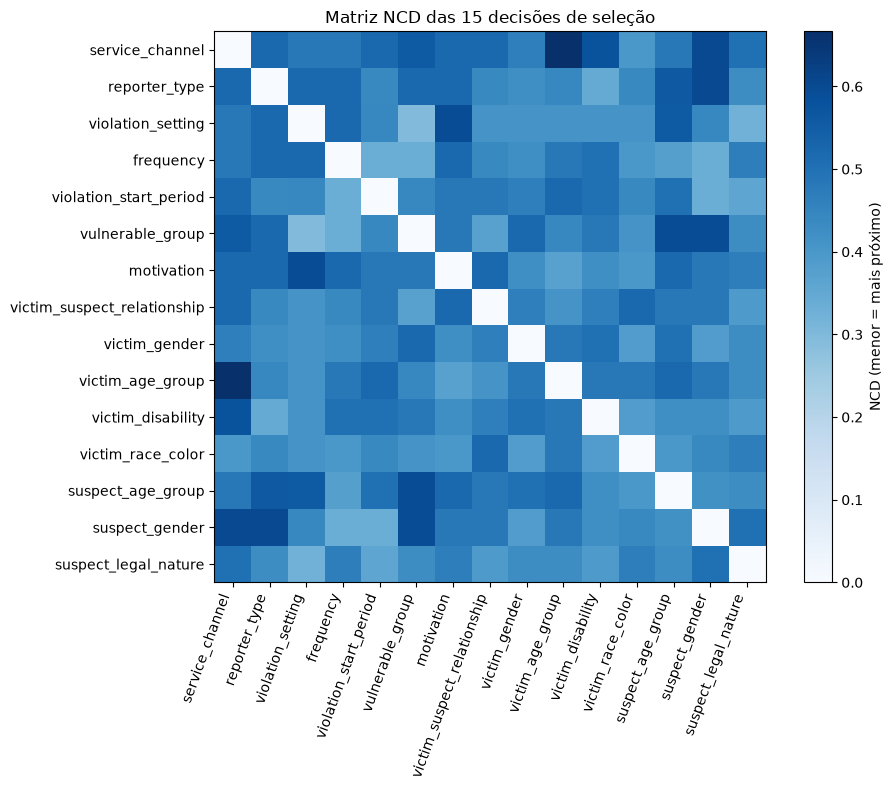

In [9]:
ncd = pd.read_csv(analysis_dir / 'ncd_matrix.csv', index_col=0)
display(ncd.round(3))
fig, ax = plt.subplots(figsize=(10, 8))
heatmap = ax.imshow(ncd.to_numpy(), cmap='Blues')
ax.set(xticks=np.arange(len(ncd)), yticks=np.arange(len(ncd)), title='Matriz NCD das 15 decisões de seleção')
ax.set_xticklabels(ncd.columns, rotation=70, ha='right')
ax.set_yticklabels(ncd.index)
fig.colorbar(heatmap, ax=ax, label='NCD (menor = mais próximo)')
fig.tight_layout()
fig.savefig(results.output_dir / 'ncd_matrix_example.png', dpi=160, bbox_inches='tight')
display(fig)
plt.close(fig)

### Da matriz à árvore e aos grupos

O DAMICORE constrói uma árvore por *Neighbor Joining* a partir das distâncias e aplica *FastGreedy* ao grafo da árvore para obter grupos de folhas. **ToyTree apenas desenha a árvore produzida pelo DAMICORE**; não infere outra árvore. O desenho mostra a topologia sem escala dos comprimentos de ramo; para comparar números, use a matriz NCD acima. Cada folha representa a decisão de incluir/excluir um campo. A proximidade de folhas não prova associação causal entre os campos nem semelhança entre denúncias.

Os grupos originais podem ter mais de quatro decisões. Nesse caso, a implementação os divide em blocos menores, usando as distâncias NCD, para que as tabelas conjuntas não fiquem esparsas demais. A tabela seguinte distingue explicitamente o grupo original do bloco efetivamente usado pelo AED.

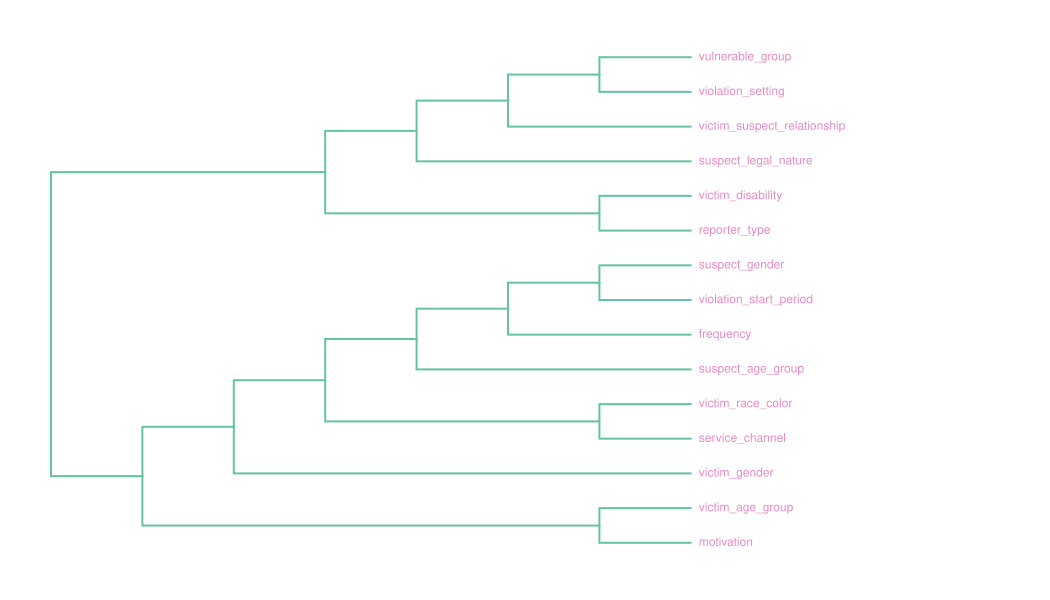

,feature,grupo original DAMICORE
0,service_channel,0
12,suspect_age_group,0
8,victim_gender,0
11,victim_race_color,0
1,reporter_type,1
10,victim_disability,1
14,suspect_legal_nature,2
7,victim_suspect_relationship,2
2,violation_setting,2
5,vulnerable_group,2


,bloco probabilístico,feature
0,1,service_channel
3,1,suspect_age_group
1,1,victim_gender
2,1,victim_race_color
4,2,reporter_type
5,2,victim_disability
9,3,suspect_legal_nature
8,3,victim_suspect_relationship
6,3,violation_setting
7,3,vulnerable_group


In [10]:
membership = pd.read_csv(analysis_dir / 'raw_membership.csv', dtype={'object_id': str, 'label': str})
tree = toytree.tree((analysis_dir / 'tree.nwk').read_text(encoding='utf-8'))
leaf_lookup = {str(row.object_id): row.feature for row in membership.itertuples()}
leaf_lookup.update({str(row.label): row.feature for row in membership.itertuples()})
tip_labels = [leaf_lookup[str(tip).strip("'\"")] for tip in tree.get_tip_labels()]
canvas, _, _ = tree.draw(tree_style='d', layout='r', width=1050, height=600, tip_labels=tip_labels, use_edge_lengths=False)
tree_path = results.output_dir / 'damicore_tree_example.svg'
toytree.save(canvas, tree_path)
display(SVG(filename=str(tree_path)))
example_blocks = results.clusters.loc[(results.clusters.seed == example_seed) & (results.clusters.generation == example_generation)]
display(membership[['feature', 'cluster']].sort_values(['cluster', 'feature']).rename(columns={'cluster': 'grupo original DAMICORE'}))
display(example_blocks[['block', 'feature']].sort_values(['block', 'feature']).rename(columns={'block': 'bloco probabilístico'}))

### Dos grupos às novas soluções

Para um bloco com `k` decisões, contamos nas 32 soluções promissoras as `2^k` combinações de bits. Somamos 1 a cada contagem (*suavização de Laplace*) e dividimos pelo total ajustado: `P(padrão) = (contagem + 1) / (32 + 2^k)`. Assim, padrões ainda não vistos continuam possíveis. Sorteamos um padrão por bloco e juntamos os bits na ordem dos 15 campos para formar uma nova solução. Até 5% das propostas são explorações aleatórias, registradas separadamente; por isso não atribuiremos todo candidato ao modelo de grupos.

In [11]:
block_table = results.probabilities.loc[(results.probabilities.seed == example_seed) & (results.probabilities.generation == example_generation) & (results.probabilities.block == 1)]
display(block_table[['features', 'pattern', 'probability']])
print(f'Soma das probabilidades do bloco: {block_table.probability.sum():.6f}')
generated = results.candidates.loc[(results.candidates.seed == example_seed) & (results.candidates.generation == example_generation) & (results.candidates.origin == 'grouped')]
if generated.empty:
    print('Nenhum candidato deste ciclo veio diretamente dos blocos; veja as origens registradas.')
else:
    display(generated[['candidate', 'mask', 'feature_count', 'origin']].head(1))
    candidate_mask = generated.iloc[0]['mask']
    print('Campos deste candidato:', [feature for feature, bit in zip(FEATURES, candidate_mask, strict=True) if bit == '1'])
display(results.candidates.loc[(results.candidates.seed == example_seed) & (results.candidates.generation == example_generation), 'origin'].value_counts().rename_axis('origem').reset_index(name='quantidade'))

,features,pattern,probability
0,"service_channel, victim_gender, victim_race_co...",0000,0.083333
1,"service_channel, victim_gender, victim_race_co...",1000,0.125000
2,"service_channel, victim_gender, victim_race_co...",0100,0.104167
3,"service_channel, victim_gender, victim_race_co...",1100,0.062500
4,"service_channel, victim_gender, victim_race_co...",0010,0.020833
5,"service_channel, victim_gender, victim_race_co...",1010,0.083333
6,"service_channel, victim_gender, victim_race_co...",0110,0.083333
7,"service_channel, victim_gender, victim_race_co...",1110,0.083333
8,"service_channel, victim_gender, victim_race_co...",0001,0.062500
9,"service_channel, victim_gender, victim_race_co...",1001,0.020833


Soma das probabilidades do bloco: 1.000000


,candidate,mask,feature_count,origin
0,1,010101101000011,7,grouped


Campos deste candidato: ['reporter_type', 'frequency', 'vulnerable_group', 'motivation', 'victim_gender', 'suspect_gender', 'suspect_legal_nature']


,origem,quantidade
0,grouped,16


A leitura de uma árvore isolada seria insuficiente. A tabela abaixo resume **todos os 15 ciclos do DAMICORE**: número de arquivos, tamanho, intervalo das distâncias, valores fora da faixa, ramos negativos e avisos. Esses indicadores não demonstram estabilidade por si só, mas impedem que grupos encontrados em arquivos muito curtos sejam apresentados sem ressalvas.

In [12]:
display(results.damicore_diagnostics[['seed', 'generation', 'elite_size', 'file_count', 'bytes_per_file', 'ncd_min', 'ncd_max', 'ncd_out_of_range_count', 'negative_branch_count', 'cluster_count', 'warnings']])

,seed,generation,elite_size,file_count,bytes_per_file,ncd_min,ncd_max,ncd_out_of_range_count,negative_branch_count,cluster_count,warnings
0,101,1,32,15,64,0.0,0.666667,0,0,5,
1,101,2,32,15,64,0.0,0.607143,0,0,5,
2,101,3,32,15,64,0.0,0.640000,0,0,4,
3,101,4,32,15,64,0.0,0.714286,0,0,5,
4,101,5,32,15,64,0.0,0.680000,0,0,5,
5,202,1,32,15,64,0.0,0.689655,0,0,4,
6,202,2,32,15,64,0.0,0.640000,0,0,5,
7,202,3,32,15,64,0.0,0.655172,0,0,5,
8,202,4,32,15,64,0.0,0.653846,0,0,5,
9,202,5,32,15,64,0.0,0.666667,0,0,5,


## 6. A busca encontrou um formulário menor sem perder qualidade?

A tabela de **validação** determina quais máscaras foram escolhidas; a de **teste** mede como esses mesmos conjuntos se comportam em abril–junho de 2026, depois de novo ajuste com denúncias anteriores ao teste. `acceptable` no teste é apenas uma checagem posterior, não um critério de escolha. `reviewed_count` é o número de denúncias dentro da capacidade de 5%; `emergencies_reviewed` conta quantas delas tinham marcação positiva. Compare também o total de emergências no denominador.

In [13]:
metric_columns = ['method', 'seed', 'acceptable', 'feature_count', 'selected_features', 'log_loss', 'brier_score', 'calibration_error', 'recall_at_capacity', 'average_precision', 'report_count', 'emergency_count', 'reviewed_count', 'emergencies_reviewed']
display(results.validation[metric_columns])
display(results.test[metric_columns])

,method,seed,acceptable,feature_count,selected_features,log_loss,brier_score,calibration_error,recall_at_capacity,average_precision,report_count,emergency_count,reviewed_count,emergencies_reviewed
0,all_fields,NaN,True,15,"service_channel, reporter_type, violation_sett...",0.098469,0.020251,0.006437,0.145161,0.039827,30000,620,1500,90
1,greedy_forward,NaN,True,3,"frequency, victim_suspect_relationship, victim...",0.097826,0.020145,0.005486,0.125806,0.037945,30000,620,1500,78
2,random,101.0,True,4,"frequency, violation_start_period, victim_gend...",0.099559,0.020209,0.006807,0.133871,0.034437,30000,620,1500,83
3,independent,101.0,True,3,"frequency, victim_suspect_relationship, suspec...",0.098888,0.020157,0.005859,0.135484,0.037776,30000,620,1500,84
4,damicore,101.0,True,5,"frequency, violation_start_period, vulnerable_...",0.097979,0.020145,0.005798,0.129032,0.038037,30000,620,1500,80
5,random,202.0,True,5,"reporter_type, frequency, motivation, victim_s...",0.098810,0.020149,0.005429,0.132258,0.039711,30000,620,1500,82
6,independent,202.0,True,3,"violation_start_period, victim_disability, sus...",0.098280,0.020149,0.005861,0.127419,0.036436,30000,620,1500,79
7,damicore,202.0,True,4,"violation_setting, frequency, violation_start_...",0.099347,0.020205,0.006331,0.133871,0.035701,30000,620,1500,83
8,random,303.0,True,5,"reporter_type, violation_setting, violation_st...",0.098216,0.020164,0.006216,0.130645,0.038594,30000,620,1500,81
9,independent,303.0,True,5,"reporter_type, frequency, victim_suspect_relat...",0.097772,0.020146,0.005398,0.129032,0.038484,30000,620,1500,80


,method,seed,acceptable,feature_count,selected_features,log_loss,brier_score,calibration_error,recall_at_capacity,average_precision,report_count,emergency_count,reviewed_count,emergencies_reviewed
0,all_fields,NaN,True,15,"service_channel, reporter_type, violation_sett...",0.090469,0.018675,0.005894,0.179703,0.045090,185787,3567,9290,641
1,greedy_forward,NaN,False,3,"frequency, victim_suspect_relationship, victim...",0.091751,0.018728,0.005723,0.114662,0.036404,185787,3567,9290,409
2,random,101.0,False,4,"frequency, violation_start_period, victim_gend...",0.092266,0.018716,0.006181,0.145781,0.038568,185787,3567,9290,520
3,independent,101.0,False,3,"frequency, victim_suspect_relationship, suspec...",0.092817,0.018750,0.006211,0.116625,0.035448,185787,3567,9290,416
4,damicore,101.0,False,5,"frequency, violation_start_period, vulnerable_...",0.091481,0.018708,0.005844,0.153911,0.038609,185787,3567,9290,549
5,random,202.0,False,5,"reporter_type, frequency, motivation, victim_s...",0.092338,0.018726,0.005690,0.146622,0.037478,185787,3567,9290,523
6,independent,202.0,False,3,"violation_start_period, victim_disability, sus...",0.091906,0.018697,0.006173,0.149706,0.041190,185787,3567,9290,534
7,damicore,202.0,False,4,"violation_setting, frequency, violation_start_...",0.092238,0.018720,0.006256,0.143818,0.039356,185787,3567,9290,513
8,random,303.0,True,5,"reporter_type, violation_setting, violation_st...",0.091198,0.018663,0.006165,0.166526,0.045165,185787,3567,9290,594
9,independent,303.0,False,5,"reporter_type, frequency, victim_suspect_relat...",0.091743,0.018729,0.005720,0.136810,0.036731,185787,3567,9290,488


### Lendo um resultado calculado

Para a primeira semente, a recuperação no teste é `emergencies_reviewed / emergency_count`: o numerador conta marcações positivas entre as denúncias que caberiam nos 5% priorizados; o denominador conta todas as marcações positivas elegíveis no teste. Os limites de qualidade abaixo foram definidos **na validação**, comparando a solução ao modelo de 15 campos.

In [14]:
test_example = results.test.loc[(results.test.method == 'damicore') & (results.test.seed == example_seed)].iloc[0]
validation_reference = results.validation.loc[results.validation.method == 'all_fields'].iloc[0]
validation_example = results.validation.loc[(results.validation.method == 'damicore') & (results.validation.seed == example_seed)].iloc[0]
print(f"Teste: {int(test_example['emergencies_reviewed'])} / {int(test_example['emergency_count'])} = {test_example['recall_at_capacity']:.3f} de recuperação")
print(f"Validação: log loss {validation_example['log_loss']:.4f} (limite {validation_reference['log_loss'] * (1 + DEFAULT_CONFIG.loss_tolerance):.4f})")
print(f"Validação: recuperação {validation_example['recall_at_capacity']:.3f} (mínimo {validation_reference['recall_at_capacity'] - DEFAULT_CONFIG.recall_tolerance:.3f})")

Teste: 549 / 3567 = 0.154 de recuperação
Validação: log loss 0.0980 (limite 0.1004)
Validação: recuperação 0.129 (mínimo 0.125)


A evolução abaixo tem **soluções avaliadas**, não denúncias, no eixo horizontal. Linhas finas são as três sementes; linhas grossas resumem cada método. A comparação de quantidade de campos só faz sentido junto da perda e dos limites de aceitabilidade da tabela anterior.

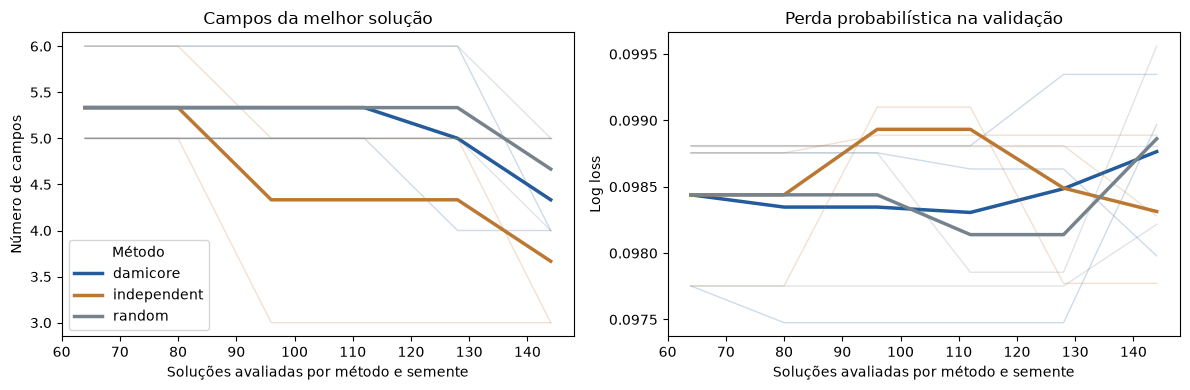

In [15]:
palette = {'random': '#77838c', 'independent': '#bc7832', 'damicore': '#245b9a'}
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for method, method_rows in results.history.groupby('method'):
    for _, seed_rows in method_rows.groupby('seed'):
        seed_rows = seed_rows.sort_values('evaluations')
        axes[0].plot(seed_rows.evaluations, seed_rows.feature_count, color=palette[method], alpha=0.22, linewidth=1)
        axes[1].plot(seed_rows.evaluations, seed_rows.log_loss, color=palette[method], alpha=0.22, linewidth=1)
    mean_rows = method_rows.groupby('evaluations', as_index=False)[['feature_count', 'log_loss']].mean()
    axes[0].plot(mean_rows.evaluations, mean_rows.feature_count, color=palette[method], linewidth=2.5, label=method)
    axes[1].plot(mean_rows.evaluations, mean_rows.log_loss, color=palette[method], linewidth=2.5, label=method)
axes[0].set(title='Campos da melhor solução', xlabel='Soluções avaliadas por método e semente', ylabel='Número de campos')
axes[1].set(title='Perda probabilística na validação', xlabel='Soluções avaliadas por método e semente', ylabel='Log loss')
axes[0].legend(title='Método')
fig.tight_layout()
fig.savefig(results.output_dir / 'search_evolution.png', dpi=160, bbox_inches='tight')
display(fig)
plt.close(fig)

### As probabilidades correspondem às frequências observadas?

O gráfico de calibração agrupa as previsões reais do teste em dez faixas e compara probabilidade média prevista com frequência de marcações positivas. A diagonal seria calibração perfeita. Mostramos o modelo completo e, **sem escolher pelo teste**, os métodos independente e DAMICORE da primeira semente. Faixas vazias não aparecem; as contagens agregadas por faixa estão em `calibration_bins.csv`. Não salvamos previsões individuais.

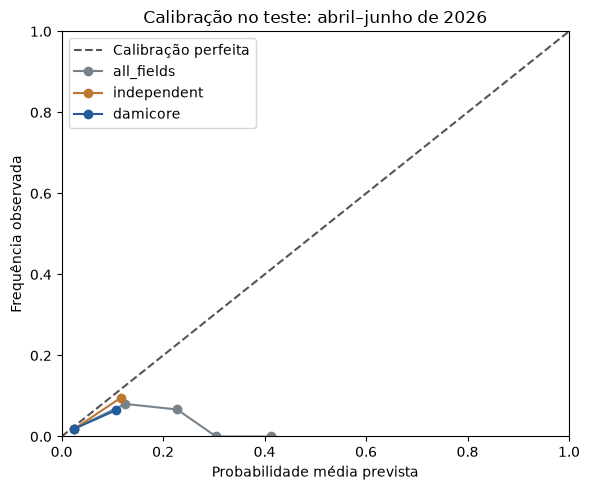

,bin,report_count,predicted_mean,observed_rate
11,0,185508,0.024921,0.019131
12,1,279,0.106660,0.064516


In [16]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], color='#555555', linestyle='--', label='Calibração perfeita')
for method in ['all_fields', 'independent', 'damicore']:
    rows = results.calibration.loc[results.calibration.method == method]
    if method != 'all_fields':
        rows = rows.loc[rows.seed == example_seed]
    rows = rows.sort_values('bin')
    ax.plot(rows.predicted_mean, rows.observed_rate, marker='o', label=method, color={'all_fields': '#77838c', **palette}.get(method))
ax.set(title='Calibração no teste: abril–junho de 2026', xlabel='Probabilidade média prevista', ylabel='Frequência observada', xlim=(0, 1), ylim=(0, 1))
ax.legend()
fig.tight_layout()
fig.savefig(results.output_dir / 'calibration.png', dpi=160, bbox_inches='tight')
display(fig)
plt.close(fig)
display(results.calibration.loc[(results.calibration.method == 'damicore') & (results.calibration.seed == example_seed), ['bin', 'report_count', 'predicted_mean', 'observed_rate']])

## 7. Conferências antes de interpretar

Estas verificações ligam os artefatos exibidos às 15 decisões e ao orçamento da busca. O código do experimento também confirma que os três métodos começam com as mesmas soluções e que o teste não entra na seleção.

In [17]:
assert len(corpus_files) == len(FEATURES) == len(ncd) == len(membership) == len(tip_labels)
assert set(ncd.index) == set(ncd.columns) == set(FEATURES) == set(tip_labels)
assert np.allclose(ncd.to_numpy(), ncd.to_numpy().T, equal_nan=False)
assert np.allclose(results.probabilities.groupby(['seed', 'generation', 'block']).probability.sum(), 1)
assert (results.history.groupby(['method', 'seed']).evaluations.max() == DEFAULT_CONFIG.evaluations_per_method).all()
assert 'source_hash' not in prepared.search_train.columns and 'emergency_status' not in FEATURES
print('Arquivos, matriz, árvore, probabilidades e orçamento: conferências satisfeitas.')

Arquivos, matriz, árvore, probabilidades e orçamento: conferências satisfeitas.


## 8. Conclusão e limites

O código abaixo mostra a classificação **calculada** da comparação. `exploratory_support` significa ganho descritivo do DAMICORE em pelo menos duas das três sementes, sem derrota na terceira e com qualidade final aceitável; não é teste de significância. `no_observed_gain` significa que nenhuma semente pareada favoreceu o método agrupado. Os outros códigos indicam resultado inconclusivo. Confira as tabelas para ver os valores, não apenas o rótulo.

Uma árvore e grupos não provam otimização: o efeito precisa aparecer frente ao AED independente e à busca aleatória, com o mesmo orçamento. Arquivos binários curtos podem tornar a NCD instável; os diagnósticos devem ser considerados antes de atribuir o ganho ao agrupamento. O limite de 5% representa uma capacidade hipotética; o número de campos representa custo de forma imperfeita. Seriam necessárias validações temporais adicionais, análise de equidade, custo real de coleta e avaliação prospectiva antes de qualquer uso no atendimento.

In [18]:
print(f'Classificação calculada: {results.conclusion}')
display(results.validation.loc[results.validation.method.isin(['independent', 'damicore']), ['method', 'seed', 'acceptable', 'feature_count', 'log_loss', 'recall_at_capacity']].sort_values(['seed', 'method']))
display(results.test.loc[results.test.method.isin(['independent', 'damicore']), ['method', 'seed', 'acceptable', 'feature_count', 'log_loss', 'recall_at_capacity']].sort_values(['seed', 'method']))

Classificação calculada: inconclusive_final_quality


,method,seed,acceptable,feature_count,log_loss,recall_at_capacity
4,damicore,101.0,True,5,0.097979,0.129032
3,independent,101.0,True,3,0.098888,0.135484
7,damicore,202.0,True,4,0.099347,0.133871
6,independent,202.0,True,3,0.098280,0.127419
10,damicore,303.0,True,4,0.098969,0.125806
9,independent,303.0,True,5,0.097772,0.129032


,method,seed,acceptable,feature_count,log_loss,recall_at_capacity
4,damicore,101.0,False,5,0.091481,0.153911
3,independent,101.0,False,3,0.092817,0.116625
7,damicore,202.0,False,4,0.092238,0.143818
6,independent,202.0,False,3,0.091906,0.149706
10,damicore,303.0,False,4,0.092908,0.130642
9,independent,303.0,False,5,0.091743,0.136810
